# Matplotlib & Seaborn — Day 8 Practical

### Python Course · Colab Notebook

---

**How to use this notebook**

1. Run every cell in order, top to bottom. Click the cell and press **Shift + Enter**.
2. **Every single line of code has a comment** explaining what it does. Read the comment, then the line.
3. Each section ends with a **YOUR TURN** cell. Those are the exercises — do them.
4. Nothing to install and nothing to upload. Colab already has both libraries, and Section 2
   builds the data.

**To save your own copy:** File → Save a copy in Drive.

---

### What we are covering

| Section | Topic |
|---|---|
| 1 | Why plot at all — Anscombe's quartet |
| 2 | Your first chart, and the three labels |
| 3 | Line and bar charts |
| 4 | Histograms — and bar vs histogram |
| 5 | Scatter and pie |
| 6 | Legends, subplots, saving |
| 7 | Seaborn — countplot, barplot, histplot |
| 8 | hue, boxplot, heatmap, pairplot |
| 9 | Choosing the right chart |
| ★ | Mini project — the class dashboard |

---

> **Charts appear underneath the cell.** If yours does not, check you actually ran the cell
> (Shift + Enter) and that the last line is `plt.show()`.

---
# Section 1 — Why plot at all?

You can already calculate a mean, a standard deviation and a correlation. So why draw pictures?

Here is the answer, and it is 50 years old.

In [1]:
import matplotlib.pyplot as plt   # the plotting library - ALWAYS imported as plt, by everybody
import seaborn as sns             # the friendlier layer on top of it - ALWAYS imported as sns
import pandas as pd               # yesterday's library, for the DataFrames
import numpy as np                # for a bit of random data later on

print("matplotlib:", plt.matplotlib.__version__)   # print the versions so you know what you have
print("seaborn   :", sns.__version__)              # Colab already has both - nothing to install

matplotlib: 3.10.0
seaborn   : 0.13.2


In [2]:
# Four small datasets, invented in 1973 by a statistician called Francis Anscombe.

anscombe = pd.DataFrame({                                    # build them as one tidy DataFrame
    "set": ["I"] * 11 + ["II"] * 11 + ["III"] * 11 + ["IV"] * 11,   # a label saying which set each row belongs to
                                                                    # ["I"] * 11 repeats the string eleven times
    "x": [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5] * 3              # sets I, II and III share the same x values
         + [8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8],                   # set IV has its own x values
    "y": [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68,   # set I
          9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74,    # set II
          7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73,   # set III
          6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89],  # set IV
})                                                           # } closes the dictionary, ) closes DataFrame( )

print(anscombe.head())      # a quick look at the first five rows

  set   x     y
0   I  10  8.04
1   I   8  6.95
2   I  13  7.58
3   I   9  8.81
4   I  11  8.33


In [3]:
# Now work out the statistics for each of the four sets.

for name in ["I", "II", "III", "IV"]:                       # one turn of the loop per set
    sub = anscombe[anscombe["set"] == name]                 # filter down to just that set (yesterday's masking)
    print(name,                                             # which set we are looking at
          "mean x:", round(sub["x"].mean(), 2),             # the average of the x column, to 2 decimals
          " mean y:", round(sub["y"].mean(), 2),            # the average of the y column
          " std y:", round(sub["y"].std(), 2),              # how spread out the y values are
          " corr:", round(sub["x"].corr(sub["y"]), 3))      # how strongly x and y move together

I mean x: 9.0  mean y: 7.5  std y: 2.03  corr: 0.816
II mean x: 9.0  mean y: 7.5  std y: 2.03  corr: 0.816
III mean x: 9.0  mean y: 7.5  std y: 2.03  corr: 0.816
IV mean x: 9.0  mean y: 7.5  std y: 2.03  corr: 0.817


Read those four lines carefully. **They are effectively identical.** Same mean x, same mean y, same
standard deviation — and the correlations are 0.816, 0.816, 0.816 and 0.817.

Any summary you could write about set I is also true of sets II, III and IV.

Now draw them.

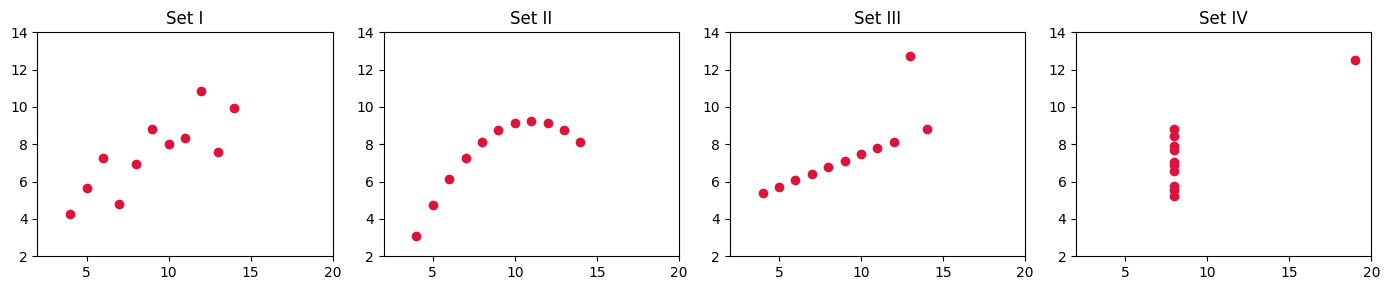

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3))     # make ONE picture with 1 row and 4 columns of charts
                                                    # figsize is (width, height) in inches
                                                    # "axes" is the list of the four panels

for i in range(4):                                  # loop 0, 1, 2, 3 - one turn per panel
    name = ["I", "II", "III", "IV"][i]              # pick the set name for this turn
    sub = anscombe[anscombe["set"] == name]         # filter to just that set
    axes[i].scatter(sub["x"], sub["y"], color="crimson")   # draw dots into panel number i
    axes[i].set_title("Set " + name)                # give that panel a title
    axes[i].set_xlim(2, 20)                         # force the same x range on all four, so they are comparable
    axes[i].set_ylim(2, 14)                         # and the same y range

plt.tight_layout()                                  # stop the titles and labels overlapping
plt.show()                                          # draw it

### That is the whole argument for this session

- **Set I** is a normal relationship.
- **Set II** is a curve, not a line at all.
- **Set III** is a perfect straight line with **one** point dragged away.
- **Set IV** is a vertical stack with **one** point miles off to the right.

The numbers said all four were the same. They were never the same.

> **Summary statistics tell you what you asked. A chart tells you what you did not think to ask.**

---
# Section 2 — Your first chart

Two lines. Everything else today is decoration on top of them.

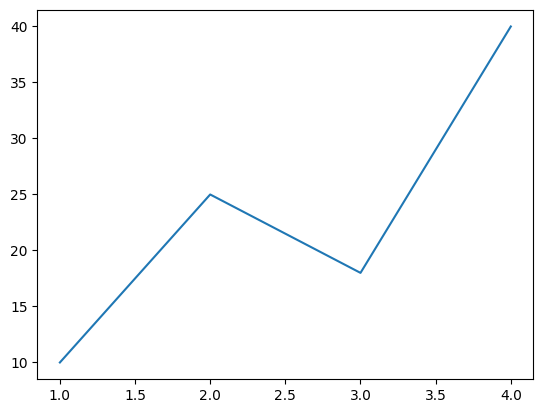

In [5]:
plt.plot([1, 2, 3, 4], [10, 25, 18, 40])   # plt.plot(x values, y values) - draws a line joining the points
                                           # the FIRST list is across, the SECOND is up
                                           # they must be the same length - four x's and four y's

plt.show()                                 # "draw it now" - always the last line of a chart cell

### Why `plt.show()` matters

In Colab the chart appears even without it. But type it anyway, for two reasons:

1. Without it, the cell's last line returns an object and Colab prints something like
   `[<matplotlib.lines.Line2D at 0x7f...>]` above your chart. Ugly.
2. It is the line that says "this chart is finished". If you draw **two charts in one cell**
   without it, the second lands on top of the first.

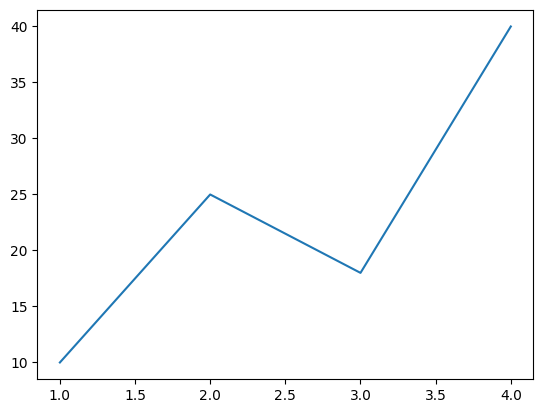

In [6]:
# The same data with the stray text line, so you can see what we are avoiding.

plt.plot([1, 2, 3, 4], [10, 25, 18, 40])   # draw the chart but do NOT call show( )
                                           # look above the chart - there is a line of [<matplotlib...>] text

### The three labels

A chart without labels is not a chart. It is a decoration. **Three lines, every time, no exceptions.**

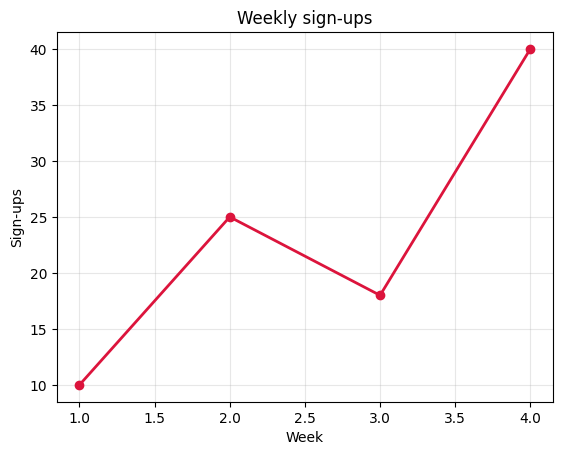

In [7]:
plt.plot([1, 2, 3, 4], [10, 25, 18, 40],   # the same data as before
         color="crimson",                  # colour of the line - names like "crimson", "steelblue", "seagreen" all work
         marker="o",                       # put a dot at each actual data point
         linewidth=2)                      # how thick the line is

plt.title("Weekly sign-ups")               # 1. what am I looking at?
plt.xlabel("Week")                         # 2. what is along the bottom?
plt.ylabel("Sign-ups")                     # 3. what is up the side?
plt.grid(True, alpha=0.3)                  # faint gridlines; alpha is see-through-ness, 0 = invisible, 1 = solid

plt.show()                                 # draw it

### ⭐ YOUR TURN 1

Draw a line chart of these five temperatures: `18, 22, 31, 27, 15` against the days `1, 2, 3, 4, 5`.
Give it a title, both axis labels, and a colour of your choosing.

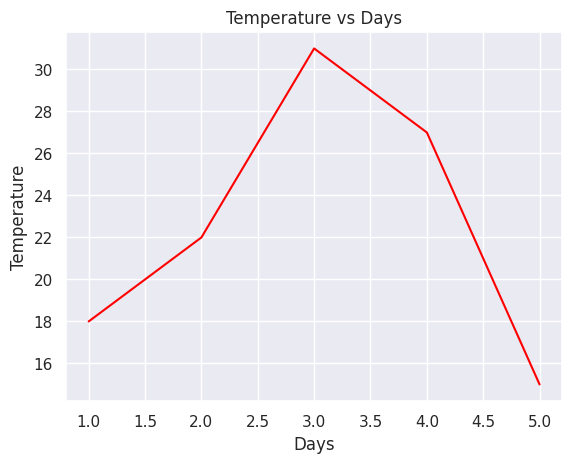

In [37]:
days = [1, 2, 3, 4, 5]              # the x values, ready for you
temps = [18, 22, 31, 27, 15]        # the y values

plt.plot(days, temps, color="red")  # TODO 1: remove the # and pick a colour
plt.title("Temperature vs Days")                    # TODO 2: what is this chart about?
plt.xlabel("Days")                   # TODO 3: what is along the bottom?
plt.ylabel("Temperature")                   # TODO 4: what is up the side?
plt.show()                        # TODO 5: draw it

---
# Section 3 — Line and bar charts

First, the data we will use for the rest of the notebook. It is the same table as yesterday.

In [9]:
students = pd.DataFrame({                                                        # the same eight students as Day 7
    "name":    ["Aisha", "Ben", "Carla", "Dev", "Eli", "Farah", "Gita", "Hari"], # who they are
    "branch":  ["CSE", "ECE", "CSE", "MECH", "ECE", "CSE", "MECH", "ECE"],       # which branch
    "year":    [2, 2, 3, 2, 3, 3, 2, 3],                                         # which year
    "maths":   [78, 55, 91, 42, 67, 83, 71, 60],                                 # marks out of 100
    "physics": [65, 71, 88, 38, 74, 97, 58, 82],                                 # more marks
    "english": [82, 60, 79, 55, 71, 68, 90, 64],                                 # more marks
})                                                                               # } closes the dict, ) the call

students["total"] = students["maths"] + students["physics"] + students["english"]   # add the three subjects up
students["average"] = (students["total"] / 3).round(1)                              # and the average, to 1 decimal

print(students)      # look at the table before plotting anything from it

    name branch  year  maths  physics  english  total  average
0  Aisha    CSE     2     78       65       82    225     75.0
1    Ben    ECE     2     55       71       60    186     62.0
2  Carla    CSE     3     91       88       79    258     86.0
3    Dev   MECH     2     42       38       55    135     45.0
4    Eli    ECE     3     67       74       71    212     70.7
5  Farah    CSE     3     83       97       68    248     82.7
6   Gita   MECH     2     71       58       90    219     73.0
7   Hari    ECE     3     60       82       64    206     68.7


### Line chart — for something with an ORDER

Use a line when the x-axis is time, or anything else that has a natural sequence.
**Never** use a line across category names — it draws a line between "CSE" and "ECE", which means nothing.

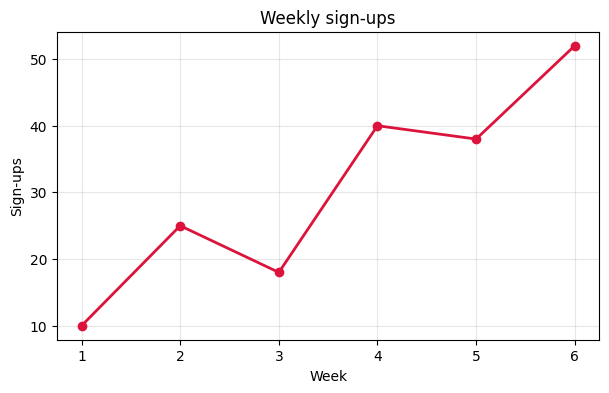

In [10]:
weeks = [1, 2, 3, 4, 5, 6]              # six weeks - these have a natural order
signups = [10, 25, 18, 40, 38, 52]      # how many people signed up each week

plt.figure(figsize=(7, 4))              # make the picture 7 inches wide and 4 tall - do this BEFORE plotting
plt.plot(weeks, signups, color="crimson", marker="o", linewidth=2)   # the line itself
plt.title("Weekly sign-ups")            # the title
plt.xlabel("Week")                      # bottom label
plt.ylabel("Sign-ups")                  # side label
plt.grid(True, alpha=0.3)               # faint gridlines
plt.show()                              # draw it

### Bar chart — for comparing CATEGORIES

This is the chart you will use most often in your career.

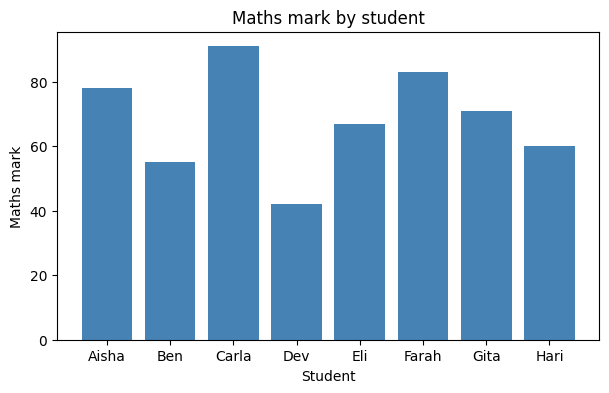

In [11]:
plt.figure(figsize=(7, 4))                                        # set the picture size first
plt.bar(students["name"], students["maths"], color="steelblue")   # plt.bar(labels, heights)
                                                                  # one bar per name, height = the maths mark
plt.title("Maths mark by student")                                # title
plt.xlabel("Student")                                             # bottom label
plt.ylabel("Maths mark")                                          # side label
plt.show()                                                        # draw it

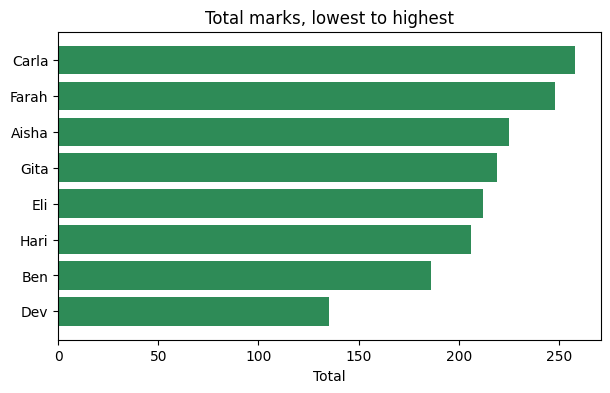

In [12]:
# Sorting first makes a bar chart much easier to read.

ordered = students.sort_values("total")            # sort the table by total, smallest first

plt.figure(figsize=(7, 4))                         # set the size
plt.barh(ordered["name"], ordered["total"],        # barh = HORIZONTAL bars; good when names are long
         color="seagreen")                         # the colour
plt.title("Total marks, lowest to highest")        # title
plt.xlabel("Total")                                # for barh, the NUMBER is now along the bottom
plt.show()                                         # draw it

> **`bar` vs `barh`:** `bar` puts categories along the bottom, `barh` puts them up the side.
> Use `barh` when the labels are long — vertical bars squash them together or turn them sideways.

> **Sort before you plot.** A bar chart in random order makes the reader do the comparing.
> A sorted one does the comparing for them.

### ⭐ YOUR TURN 2

Draw a bar chart of each student's **physics** mark. Sort the table by physics first, and give the
chart all three labels.

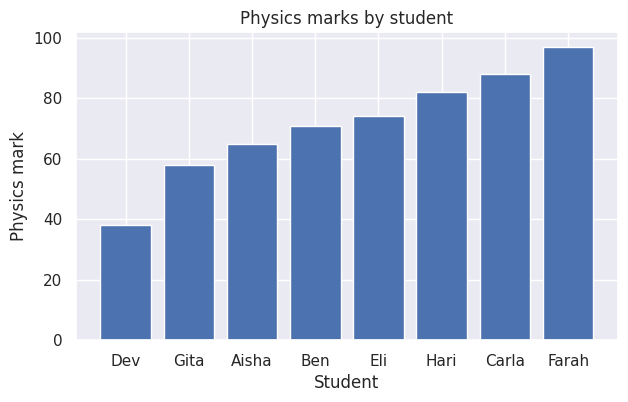

In [39]:
by_physics = students.sort_values("physics")               # TODO 1: which column do you sort by?
plt.figure(figsize=(7, 4))                           # TODO 2: set the size
plt.bar(by_physics["name"], by_physics["physics"])            # TODO 3: names for the labels, physics for the heights
plt.title("Physics marks by student")                                       # TODO 4
plt.xlabel("Student")                                      # TODO 5
plt.ylabel("Physics mark")                                      # TODO 6
plt.show()                                           # TODO 7

---
# Section 4 — Histograms

A histogram answers a completely different question from a bar chart:
**"what SHAPE is this spread of numbers?"**

In [14]:
rng = np.random.default_rng(42)          # a random number generator with a fixed seed, so everyone matches
exam = rng.normal(65, 12, 200).round()   # 200 fake exam marks: average 65, spread 12, rounded to whole numbers

print("how many marks:", len(exam))      # 200
print("first ten     :", exam[:10])      # a peek at the start
print("average       :", round(exam.mean(), 1))   # roughly 65, as we asked for

how many marks: 200
first ten     : [69. 53. 74. 76. 42. 49. 67. 61. 65. 55.]
average       : 64.7


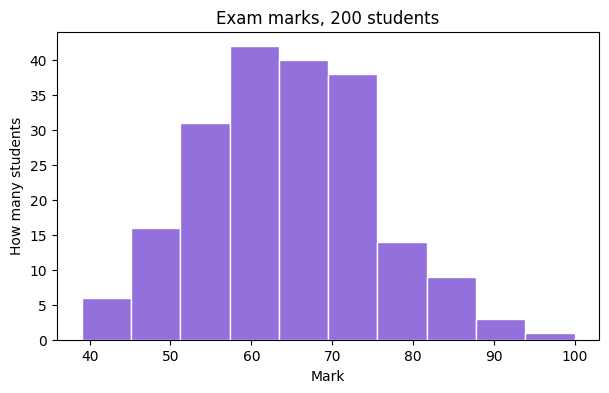

In [15]:
plt.figure(figsize=(7, 4))                      # set the picture size
plt.hist(exam,                                  # the ONE column of numbers we want the shape of
         bins=10,                               # chop the range into 10 buckets
         color="mediumpurple",                  # bar colour
         edgecolor="white")                     # a white line between bars, so you can see where each one ends
plt.title("Exam marks, 200 students")           # title
plt.xlabel("Mark")                              # the bottom is the MARK, not the student
plt.ylabel("How many students")                 # the height is a COUNT
plt.show()                                      # draw it

### `bins` — the one setting that matters

Too few and everything blurs into one block. Too many and it looks like noise. Try a few.

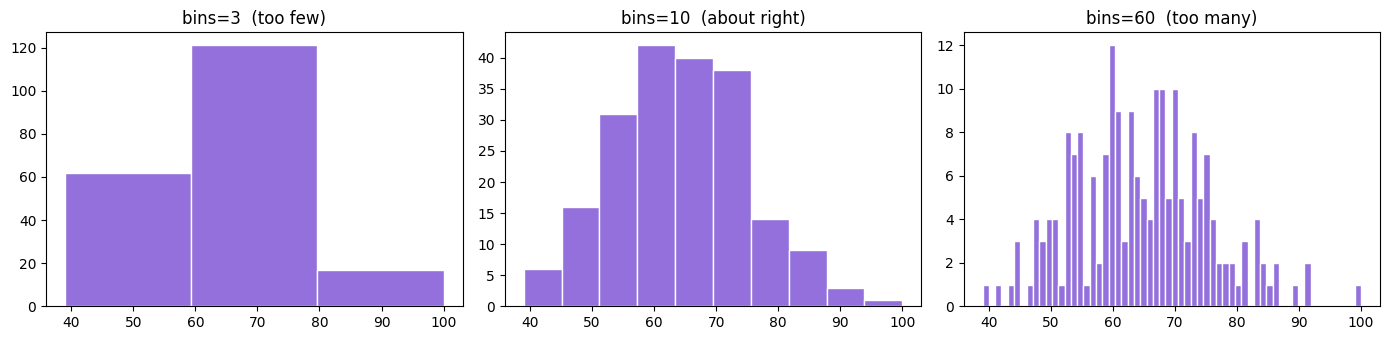

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))   # one row, three panels, so we can compare

axes[0].hist(exam, bins=3, color="mediumpurple", edgecolor="white")    # too few - no detail
axes[0].set_title("bins=3  (too few)")                                 # label the panel

axes[1].hist(exam, bins=10, color="mediumpurple", edgecolor="white")   # about right
axes[1].set_title("bins=10  (about right)")                            # label it

axes[2].hist(exam, bins=60, color="mediumpurple", edgecolor="white")   # too many - just noise
axes[2].set_title("bins=60  (too many)")                               # label it

plt.tight_layout()                                                     # keep the titles apart
plt.show()                                                             # draw it

### Bar vs histogram — the confusion of the whole session

They look almost identical on screen. They answer completely different questions.

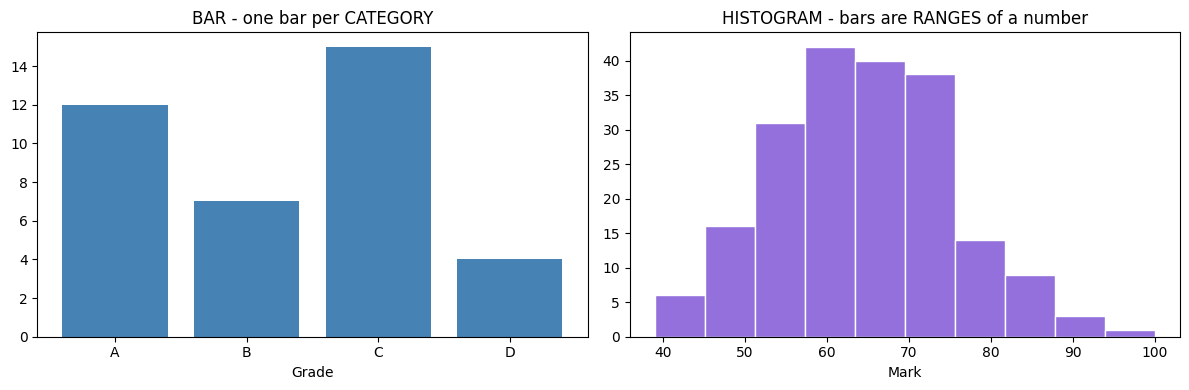

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))     # two panels side by side

axes[0].bar(["A", "B", "C", "D"], [12, 7, 15, 4], color="steelblue")   # a BAR chart: four named categories
axes[0].set_title("BAR - one bar per CATEGORY")                        # title for the left panel
axes[0].set_xlabel("Grade")                                            # the x-axis holds NAMES

axes[1].hist(exam, bins=10, color="mediumpurple", edgecolor="white")   # a HISTOGRAM: one number column
axes[1].set_title("HISTOGRAM - bars are RANGES of a number")           # title for the right panel
axes[1].set_xlabel("Mark")                                             # the x-axis holds NUMBER RANGES

plt.tight_layout()                                                     # keep them apart
plt.show()                                                             # draw it

| | Bar chart | Histogram |
|---|---|---|
| The x-axis holds | **categories** — names, branches, grades (a category can be a number, like a year) | **ranges** of one number column |
| You choose | the categories (they are in your data) | the number of **bins** |
| Bars touch? | no — there are gaps | yes — the ranges run into each other |
| The question | "how does A compare to B?" | "what shape is this spread?" |

> **A histogram needs a lot of values.** Eight students is not enough — you get a handful of bars
> of height 1 and 2, which tells you nothing. That is why this section uses 200 fake marks.

---
# Section 5 — Scatter and pie

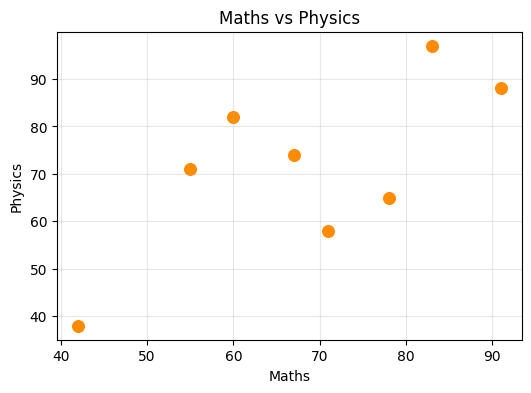

In [18]:
plt.figure(figsize=(6, 4))                       # set the size
plt.scatter(students["maths"],                   # x = the maths marks
            students["physics"],                 # y = the physics marks
            color="darkorange",                  # dot colour
            s=70)                                # s = dot SIZE (the default is small)
plt.title("Maths vs Physics")                    # title
plt.xlabel("Maths")                              # bottom label
plt.ylabel("Physics")                            # side label
plt.grid(True, alpha=0.3)                        # faint gridlines help you read positions
plt.show()                                       # draw it

### Reading a scatter

- Dots drifting **up to the right** → the two go together.
- Dots drifting **down to the right** → one rises as the other falls.
- A **shapeless cloud** → no relationship at all.

> ⚠️ **A scatter shows that two things MOVE TOGETHER. It does not show that one CAUSES the other.**
> Ice cream sales and drownings both rise in summer. Ice cream does not cause drownings.

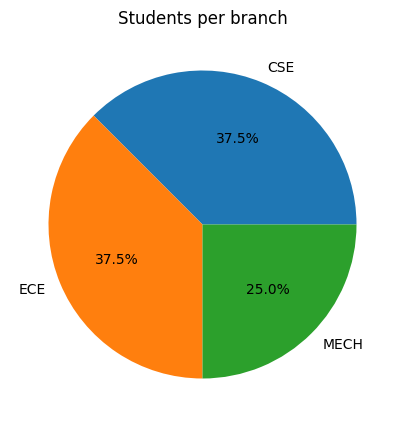

In [19]:
counts = students["branch"].value_counts()       # yesterday's method: how many students per branch

plt.figure(figsize=(5, 5))                       # pies look best square
plt.pie(counts.values,                           # the sizes of the slices
        labels=counts.index.tolist(),            # the label for each slice - the index holds the branch names
        autopct="%1.1f%%")                       # write the percentage on each slice, to 1 decimal place
                                                 # (with 0 decimals, 37.5 + 37.5 + 25 rounds to 38+38+25 = 101%)
plt.title("Students per branch")                 # title
plt.show()                                       # draw it

### About pie charts

People are bad at comparing **angles**. Is that slice 22% or 27%? You cannot tell by looking.
The same numbers as a bar chart are read correctly in a second.

> **The honest rule: if you can use a bar chart instead, use a bar chart.**
> Pie charts are for two or three slices, or for when somebody senior insists.

### ⭐ YOUR TURN 3

1. Draw a scatter of `english` against `maths`. Label everything.
2. Looking at your chart — do the two go together, or not?

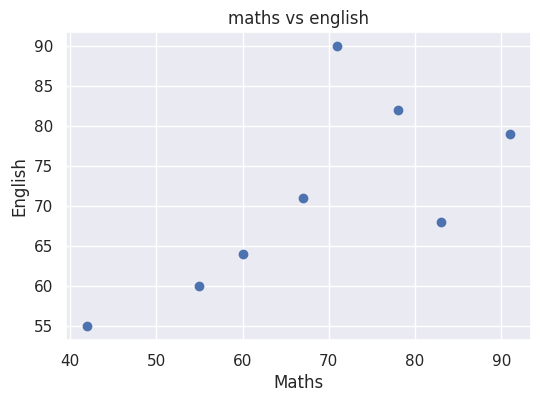

In [40]:
# YOUR TURN 3 - write your code here

plt.figure(figsize=(6, 4))                    # TODO 1: set the size
plt.scatter(students["maths"], students["english"])     # TODO 2: maths on x, english on y
plt.title("maths vs english")                                # TODO 3
plt.xlabel("Maths")                               # TODO 4
plt.ylabel("English")                               # TODO 5
plt.show()                                    # TODO 6

---
# Section 6 — Legends, subplots, saving

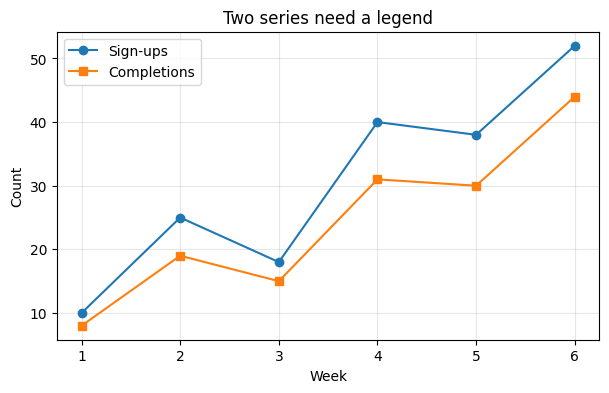

In [21]:
completions = [8, 19, 15, 31, 30, 44]           # a second series to plot alongside the sign-ups

plt.figure(figsize=(7, 4))                                            # set the size
plt.plot(weeks, signups, marker="o", label="Sign-ups")                # label= names this line
plt.plot(weeks, completions, marker="s", label="Completions")         # marker="s" is a square
plt.title("Two series need a legend")                                 # title
plt.xlabel("Week")                                                    # bottom label
plt.ylabel("Count")                                                   # side label
plt.legend()                                                          # WITHOUT this line, no legend box appears
plt.grid(True, alpha=0.3)                                             # gridlines
plt.show()                                                            # draw it

> **You need both.** `label=` sets the text; `plt.legend()` draws the box. Setting `label=` and
> forgetting `plt.legend()` is the commonest miss — the chart looks fine and nobody can tell
> which line is which.

**Markers:** `"o"` circle · `"s"` square · `"^"` triangle · `"*"` star · `"x"` cross
**Line styles:** `"-"` solid · `"--"` dashed · `":"` dotted

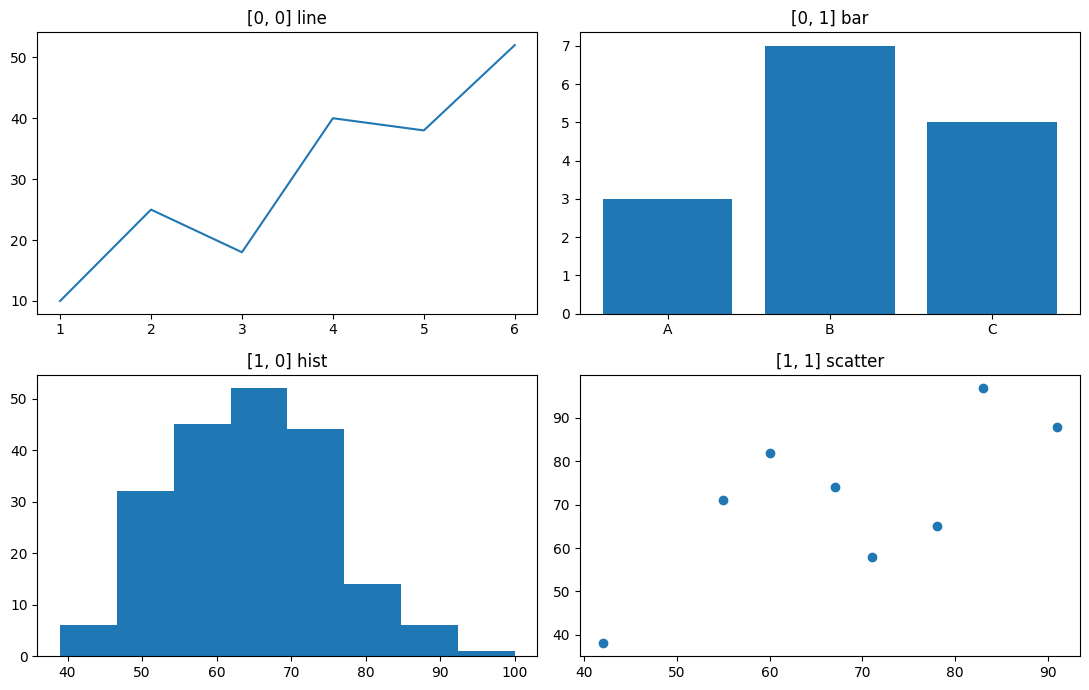

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))         # a 2 x 2 grid of panels
                                                        # "fig" is the whole picture, "axes" is the grid of panels

axes[0, 0].plot(weeks, signups)                         # top-left  panel: a line
axes[0, 0].set_title("[0, 0] line")                     # note set_title, NOT plt.title, inside a panel

axes[0, 1].bar(["A", "B", "C"], [3, 7, 5])              # top-right panel: a bar chart
axes[0, 1].set_title("[0, 1] bar")                      # its title

axes[1, 0].hist(exam, bins=8)                           # bottom-left panel: a histogram
axes[1, 0].set_title("[1, 0] hist")                     # its title

axes[1, 1].scatter(students["maths"], students["physics"])   # bottom-right panel: a scatter
axes[1, 1].set_title("[1, 1] scatter")                       # its title

plt.tight_layout()                                      # stop the titles colliding - almost always needed
plt.show()                                              # draw it

### The one thing that changes inside a subplot

| Outside a subplot | Inside a panel |
|---|---|
| `plt.title("x")` | `axes[0, 1].set_title("x")` |
| `plt.xlabel("x")` | `axes[0, 1].set_xlabel("x")` |
| `plt.ylabel("x")` | `axes[0, 1].set_ylabel("x")` |

The `plt.` versions only know about the **last** chart you touched. Inside a grid you must say
which panel you mean.

> **One row only?** Then `axes` is a flat list: `axes[0]`, `axes[1]`, not `axes[0, 0]`.

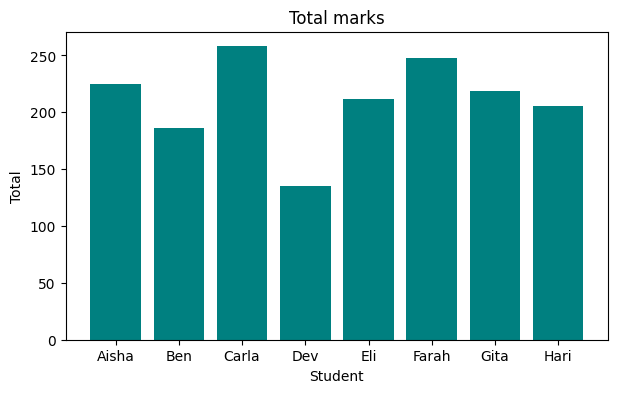

saved as my_chart.png


In [23]:
plt.figure(figsize=(7, 4))                          # set the size
plt.bar(students["name"], students["total"], color="teal")   # a simple chart to save
plt.title("Total marks")                            # title
plt.xlabel("Student")                               # bottom label
plt.ylabel("Total")                                 # side label

plt.savefig("my_chart.png",                         # the filename to save as
            dpi=150,                                # sharpness - 150 is good for a report, 300 for print
            bbox_inches="tight")                    # trims the border so labels are not cut off

plt.show()                                          # show it AFTER saving - see the warning below

print("saved as my_chart.png")                      # confirm it happened

> ⚠️ **`savefig` must come BEFORE `show()`.**
>
> `show()` draws the figure and then clears it. If you call `savefig` afterwards you save a
> **blank white square** — and the code gives you no error at all. This will cost somebody
> twenty minutes today; do not let it be you.

**Where did the file go?** Colab's session storage. Click the **folder icon** in the left sidebar
to see it, and the download arrow next to it to keep a copy. It disappears when the session ends.

---
# Section 7 — Seaborn

Seaborn is not a replacement for matplotlib. It is matplotlib with the boring parts filled in:
it speaks DataFrame, it does the statistics for you, and its defaults look better.

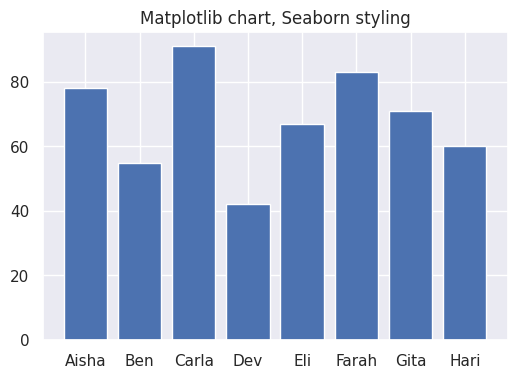

In [24]:
sns.set_theme()      # turn on Seaborn's styling for EVERY chart from here on, including matplotlib ones
                     # run this once near the top of a notebook and everything improves

plt.figure(figsize=(6, 4))                          # set the size
plt.bar(students["name"], students["maths"])        # a plain MATPLOTLIB chart...
plt.title("Matplotlib chart, Seaborn styling")      # ...but it picked up the new look
plt.show()                                          # draw it

### `countplot` and `barplot` — know the difference

This is the pair people get wrong, and getting it wrong gives you a chart that looks perfectly
plausible and says the wrong thing.

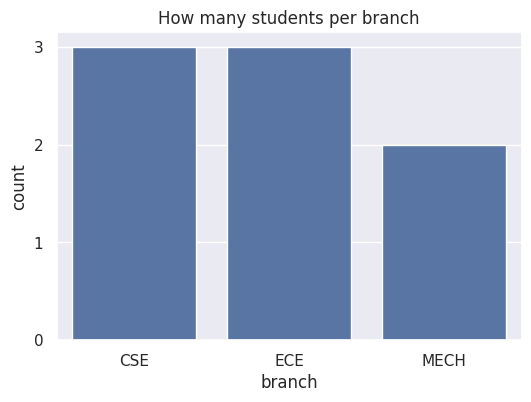

In [25]:
from matplotlib.ticker import MaxNLocator          # a helper that forces whole-number axis ticks

plt.figure(figsize=(6, 4))                          # set the size
ax = sns.countplot(data=students, x="branch")       # data= the DataFrame, x= the COLUMN NAME as text
                                                    # notice there is no y= at all
                                                    # countplot COUNTS THE ROWS in each branch
                                                    # it hands back the axes, which we save as "ax"
ax.yaxis.set_major_locator(MaxNLocator(integer=True))   # counts are whole numbers - no "2.5 students"
plt.title("How many students per branch")           # title
plt.show()                                          # draw it

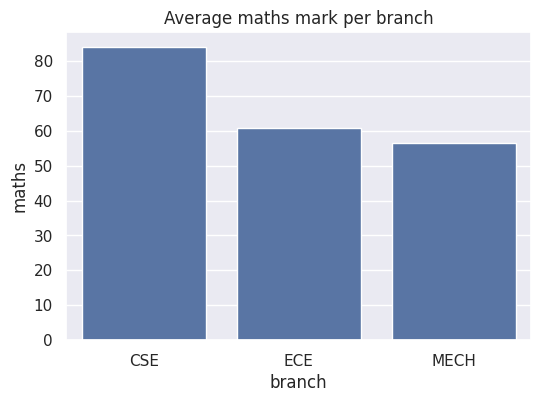

In [26]:
plt.figure(figsize=(6, 4))                          # set the size
sns.barplot(data=students,                          # the DataFrame
            x="branch",                             # what to group by
            y="maths",                              # what to AVERAGE - this is the difference
            errorbar=None)                          # turn off the thin black error bars (see below)
plt.title("Average maths mark per branch")          # title
plt.show()                                          # draw it

| | `countplot` | `barplot` |
|---|---|---|
| Counts what | **rows** in each group | nothing — it **averages** |
| Needs | just `x=` | `x=` **and** `y=` |
| Bar height is | how many | the mean of `y` |

> **About `errorbar=None`:** by default `barplot` draws a thin black line through each bar. It is a
> 95% confidence interval — a statistical estimate of how sure we are about that average. With only
> two or three students per branch it is meaningless, so we turn it off. On real data with hundreds
> of rows, leave it on.

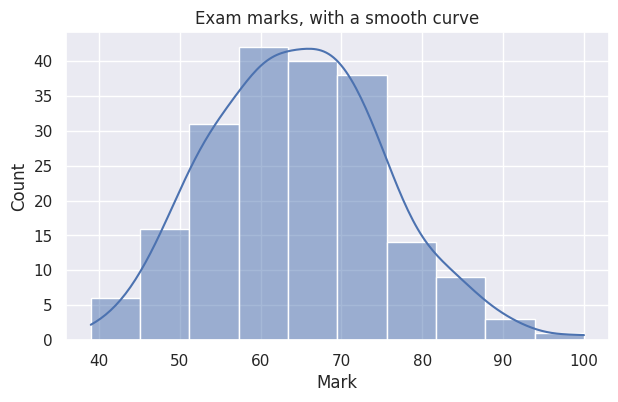

In [27]:
plt.figure(figsize=(7, 4))                          # set the size
sns.histplot(exam,                                  # the same 200 exam marks
             bins=10,                               # same bins setting as matplotlib
             kde=True)                              # kde=True adds a smooth curve over the bars
                                                    # it is the shape the bars are hinting at
plt.title("Exam marks, with a smooth curve")        # title
plt.xlabel("Mark")                                  # bottom label
plt.show()                                          # draw it

### ⭐ YOUR TURN 4

1. A `countplot` of how many students are in each **year**.
2. A `barplot` of the average **total** per **branch**, with the error bars turned off.

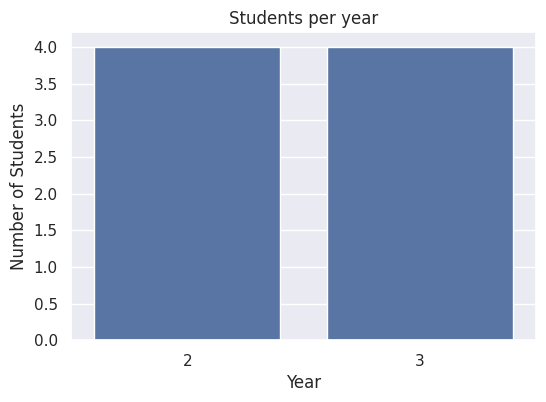

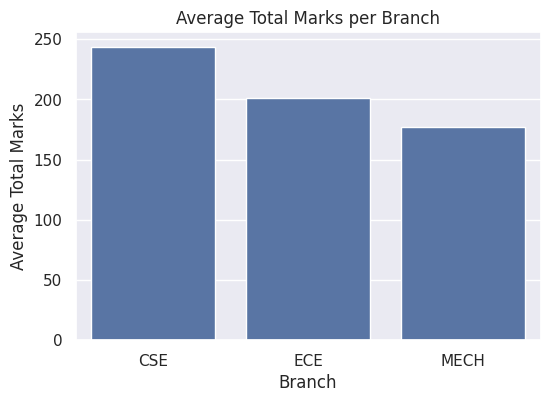

In [42]:
# YOUR TURN 4 - write your code here

plt.figure(figsize=(6, 4))                                  # TODO 1: set the size
sns.countplot(data=students, x="year")                         # TODO 2: which column holds the year?
plt.title("Students per year")                                              # TODO 3
plt.xlabel("Year")                               # TODO 4
plt.ylabel("Number of Students")                               # TODO 5
plt.show()                                                  # TODO 6

plt.figure(figsize=(6, 4))                                  # TODO 5: set the size
sns.barplot(data=students, x="branch", y="total", errorbar=None)     # TODO 6: group by branch, average the total
plt.title("Average Total Marks per Branch")                                              # TODO 7
plt.xlabel("Branch")                               # TODO 4
plt.ylabel("Average Total Marks")                               # TODO 5
plt.show()                                                  # TODO 8

---
# Section 8 — hue, boxplot, heatmap, pairplot

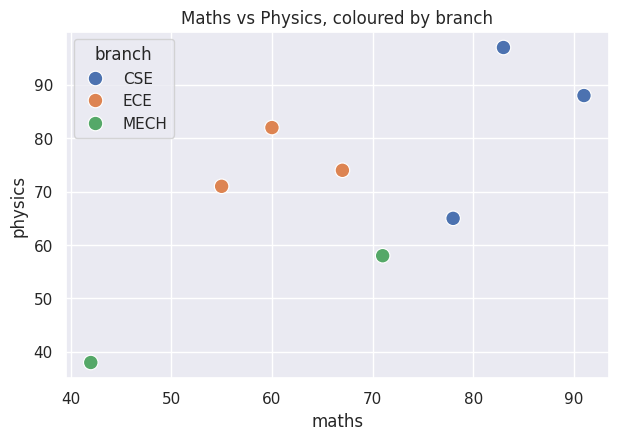

In [29]:
plt.figure(figsize=(7, 4.5))                        # set the size
sns.scatterplot(data=students,                      # the DataFrame
                x="maths",                          # x-axis column
                y="physics",                        # y-axis column
                hue="branch",                       # COLOUR the dots by branch - and build the legend automatically
                s=110)                              # dot size
plt.title("Maths vs Physics, coloured by branch")   # title
plt.show()                                          # draw it

> **`hue=` is the most useful word in Seaborn.** It works on `scatterplot`, `barplot`, `countplot`,
> `boxplot` and `histplot` — same word, same effect, and the legend appears on its own.

> **Why do these cells only set a title?** The "three labels every time" rule still stands — but
> Seaborn already writes the axis labels for you, from the column names you passed to `x=` and `y=`.
> It cannot guess a title, so that one is still your job. If the auto-generated axis labels are ugly
> (`"total"` rather than `"Total marks"`), override them with `plt.xlabel()` as usual.

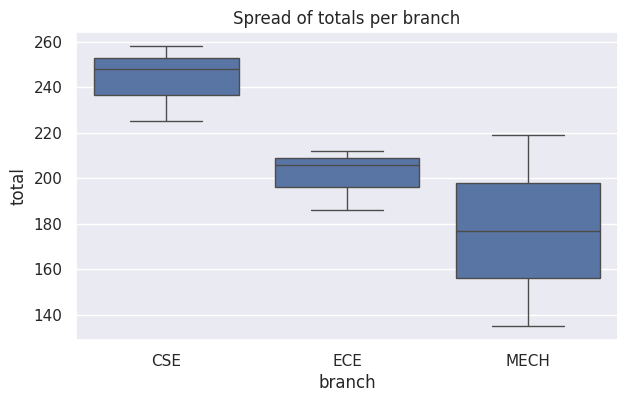

In [30]:
plt.figure(figsize=(7, 4))                          # set the size
sns.boxplot(data=students, x="branch", y="total")   # one box per branch, showing the spread of totals
plt.title("Spread of totals per branch")            # title
plt.show()                                          # draw it

### How to read a boxplot

| Part of the picture | What it means |
|---|---|
| the **line in the middle** | the **median** — half the values above it, half below |
| the **box** | the middle 50% of the data (25th to 75th percentile) |
| the **whiskers** | the reach of the rest of the data, ignoring outliers |
| **dots outside** the whiskers | outliers — unusually far from everything else |

A **tall box** means the group is spread out. A **short box** means it is consistent.

> ⚠️ **Our MECH group has only two students**, so its box is drawn from just two numbers and means
> almost nothing. A boxplot needs a decent number of values per group before the quartiles are real.

         maths  physics  english  total
maths     1.00     0.70     0.70   0.97
physics   0.70     1.00     0.13   0.81
english   0.70     0.13     1.00   0.66
total     0.97     0.81     0.66   1.00


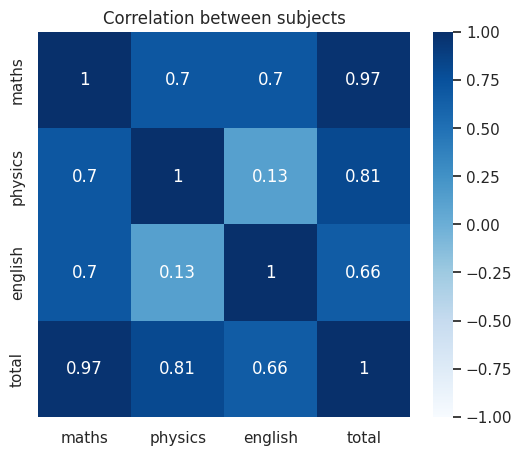

In [31]:
numbers_only = students[["maths", "physics", "english", "total"]]   # pick just the number columns
corr = numbers_only.corr().round(2)                                 # .corr( ) works out how each pair moves together
                                                                    # .round(2) trims it to 2 decimals

print(corr)                                         # look at the numbers first

plt.figure(figsize=(6, 5))                          # set the size
sns.heatmap(corr,                                   # the table of correlations
            annot=True,                             # write the number inside each square
            cmap="Blues",                           # the colour scheme - darker means higher
            vmin=-1, vmax=1)                        # fix the scale from -1 to +1 so colours mean the same thing
plt.title("Correlation between subjects")           # title
plt.show()                                          # draw it

### Reading a correlation

- **+1** = they rise together perfectly
- **0** = no relationship at all
- **−1** = one rises as the other falls

The diagonal is always **1**, because every column correlates perfectly with itself.

In our data, maths correlates **0.70 with both physics and english** — but physics and english
correlate only **0.13** with each other.

That is worth a second look. Maths tracks both of the others, yet those two barely track each other
at all. Two things can both be related to a third thing and still have almost nothing to do with
one another.

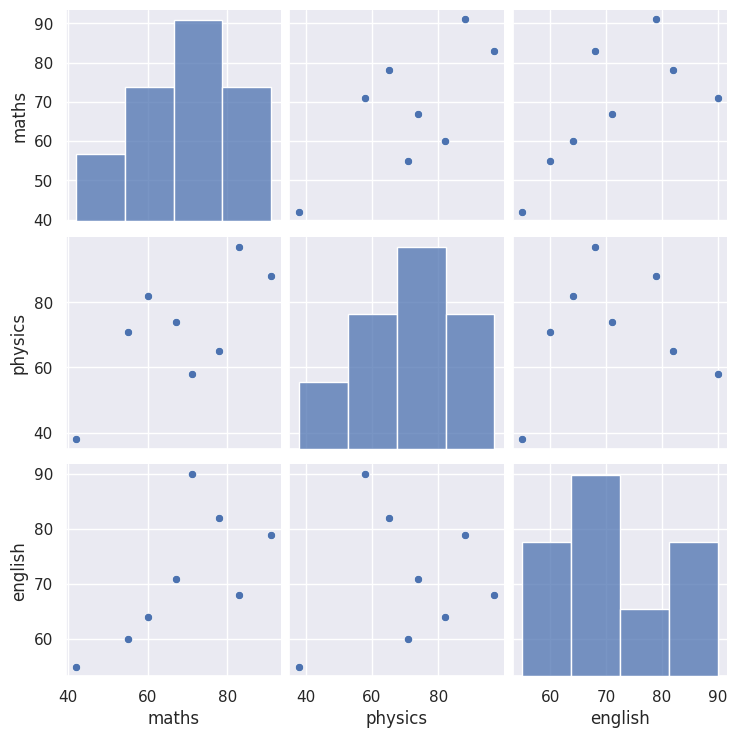

In [32]:
sns.pairplot(students[["maths", "physics", "english"]])   # draws EVERY column against every other column
                                                          # with a histogram of each column down the diagonal
plt.show()                                                # draw it

> `pairplot` is wonderful for a first look at a small table. It is far too slow for a big one —
> ten columns means a hundred little charts.

> ⚠️ **`pairplot` is the exception to "a Seaborn chart is a matplotlib chart".** Most Seaborn
> functions draw into one set of axes, so `plt.title()` works on them. `pairplot` builds a whole
> grid, so `plt.title()` afterwards lands **inside one random panel**. To title a pairplot, save it
> first — `g = sns.pairplot(...)` — then `g.figure.suptitle("Your title")`.

---
# Section 9 — Choosing the right chart

Start from **the sentence you want to say out loud**, then pick the chart that says it.

| My question | Chart | Code |
|---|---|---|
| How did this change over time? | line | `plt.plot(x, y)` |
| How do these categories compare? | bar | `plt.bar(names, values)` |
| How many of each category? | count | `sns.countplot(data=df, x="col")` |
| What is the average per category? | bar | `sns.barplot(data=df, x=, y=, errorbar=None)` |
| What shape is this one column? | histogram | `sns.histplot(df["col"], bins=10)` |
| How spread out is each group? | box | `sns.boxplot(data=df, x=, y=)` |
| Do these two numbers move together? | scatter | `sns.scatterplot(data=df, x=, y=, hue=)` |
| What relates to what, across everything? | heatmap | `sns.heatmap(df.corr(), annot=True)` |

**Worked examples**

- *"CSE students score higher on average"* → a **bar** chart (`sns.barplot`)
- *"Most people scored around 65"* → a **histogram**
- *"Sign-ups grew steadily all term"* → a **line**
- *"Good at maths usually means good at physics"* → a **scatter**

---
# ★ Mini project — the class dashboard

Four charts, one figure. This is the deliverable — everything from today in one picture.

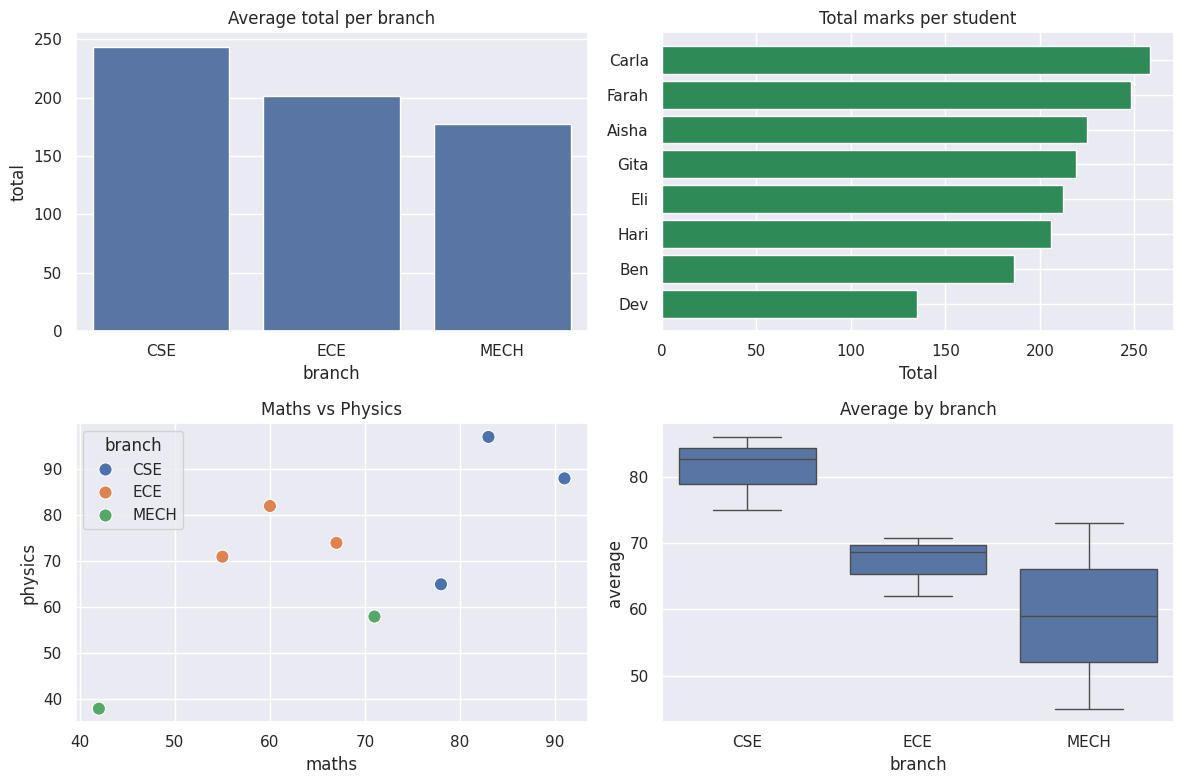

saved as dashboard.png


In [33]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))     # a 2 x 2 grid, nice and big

# ---- top-left: average total per branch ----
sns.barplot(data=students, x="branch", y="total",   # group by branch, average the total
            errorbar=None,                          # no error bars - too few students per branch
            ax=axes[0, 0])                          # ax= says WHICH panel to draw into
axes[0, 0].set_title("Average total per branch")    # its title

# ---- top-right: every student's total, sorted ----
ranked = students.sort_values("total")              # sort so the bars climb
axes[0, 1].barh(ranked["name"], ranked["total"],    # horizontal bars - the names have room
                color="seagreen")                   # colour
axes[0, 1].set_title("Total marks per student")     # its title
axes[0, 1].set_xlabel("Total")                      # the number axis is along the bottom for barh

# ---- bottom-left: maths vs physics, coloured by branch ----
sns.scatterplot(data=students, x="maths", y="physics",   # the two number columns
                hue="branch",                            # colour by branch
                s=90,                                    # dot size
                ax=axes[1, 0])                           # which panel
axes[1, 0].set_title("Maths vs Physics")                 # its title

# ---- bottom-right: spread of averages per branch ----
sns.boxplot(data=students, x="branch", y="average",      # one box per branch
            ax=axes[1, 1])                               # which panel
axes[1, 1].set_title("Average by branch")                # its title

plt.tight_layout()                                  # ALWAYS the last line before show - stops collisions
plt.savefig("dashboard.png", dpi=150, bbox_inches="tight")   # save it BEFORE show( )
plt.show()                                          # draw it

print("saved as dashboard.png")                     # confirm

### What to notice

1. **`ax=` is the key.** Every Seaborn function takes `ax=` to say which panel it belongs in.
   Leave it out and everything piles into the last panel.
2. **Seaborn and matplotlib mix freely.** Three panels are Seaborn, one is a plain `plt.barh`.
   They coexist in the same figure without any fuss.
3. **`tight_layout()` then `savefig` then `show`.** In that order, every time.

---
### ⭐ FINAL CHALLENGE

Add cells below and build these:

1. A bar chart of the **average mark per subject** — maths, physics and english as three bars.
   *(Hint: `students[["maths", "physics", "english"]].mean()` gives you a Series. Its `.index`
   holds the subject names and its `.values` hold the averages.)*
2. A histogram of all 24 marks combined — every student's maths, physics and english in one list.
   *(Hint: `students["maths"] + students["physics"]` ADDS the columns element-wise and gives you 8
   totals, which is not what you want. To stick them end to end you need plain Python lists:
   `students["maths"].tolist() + students["physics"].tolist() + students["english"].tolist()`.)*
3. A `countplot` of `branch` with `hue="year"` — how many students of each year, in each branch.
4. Save your favourite chart of the day as a PNG at `dpi=300` and download it from the folder panel.

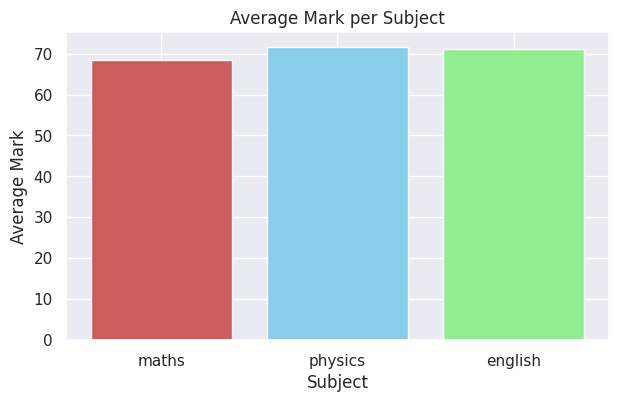

In [45]:
# FINAL CHALLENGE - your code here

# 1. A bar chart of the average mark per subject — maths, physics and english as three bars.
subject_averages = students[["maths", "physics", "english"]].mean()

plt.figure(figsize=(7, 4))
plt.bar(subject_averages.index, subject_averages.values, color=["indianred", "skyblue", "lightgreen"])
plt.title("Average Mark per Subject")
plt.xlabel("Subject")
plt.ylabel("Average Mark")
plt.show()

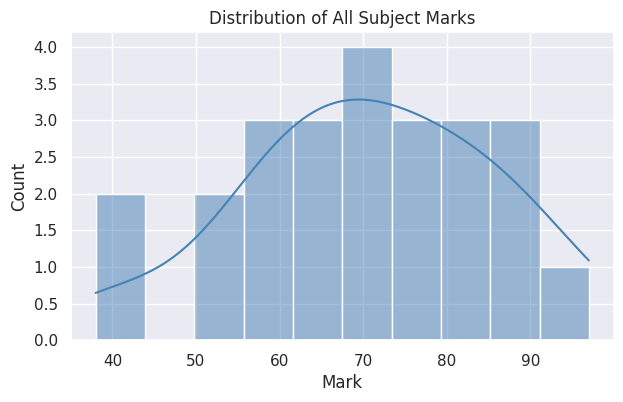

In [46]:
# 2. A histogram of all 24 marks combined — every student's maths, physics and english in one list.
all_marks = students["maths"].tolist() + students["physics"].tolist() + students["english"].tolist()

plt.figure(figsize=(7, 4))
sns.histplot(all_marks, bins=10, kde=True, color="steelblue")
plt.title("Distribution of All Subject Marks")
plt.xlabel("Mark")
plt.ylabel("Count")
plt.show()

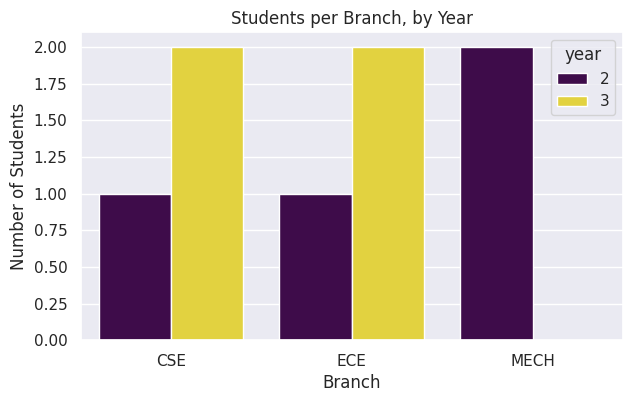

In [47]:
# 3. A countplot of branch with hue="year" — how many students of each year, in each branch.
plt.figure(figsize=(7, 4))
sns.countplot(data=students, x="branch", hue="year", palette="viridis")
plt.title("Students per Branch, by Year")
plt.xlabel("Branch")
plt.ylabel("Number of Students")
plt.show()

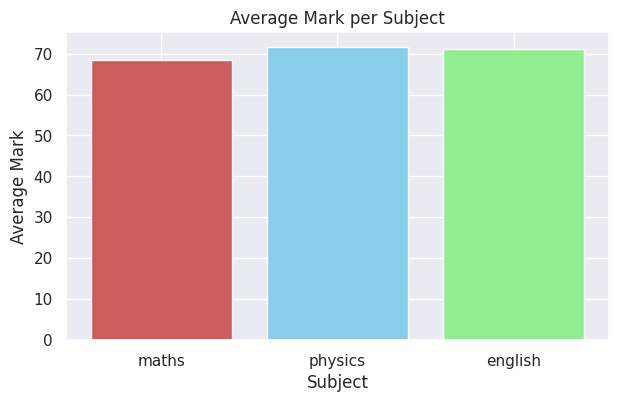

Saved 'average_mark_per_subject.png' to session storage.


In [48]:
# 4. Save your favourite chart of the day as a PNG at dpi=300 and download it from the folder panel.
# I will save the 'Average Mark per Subject' chart as it effectively summarizes key data.
subject_averages = students[["maths", "physics", "english"]].mean()

plt.figure(figsize=(7, 4))
plt.bar(subject_averages.index, subject_averages.values, color=["indianred", "skyblue", "lightgreen"])
plt.title("Average Mark per Subject")
plt.xlabel("Subject")
plt.ylabel("Average Mark")
plt.savefig("average_mark_per_subject.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved 'average_mark_per_subject.png' to session storage.")

---

## Ten lines to take home

1. **Numbers can lie; pictures catch it.** Anscombe: same statistics, four different shapes.
2. **A chart is `plt.plot()` then `plt.show()`.** Everything else is decoration.
3. **Title, xlabel, ylabel — every time.** An unlabelled chart is not finished.
4. **Line for order, bar for categories.** Never a line across category names.
5. **Bar = categories. Histogram = one number column.** The commonest mix-up in the topic.
6. **A scatter shows togetherness, not cause.** Ice cream does not cause drownings.
7. **Seaborn speaks DataFrame:** `data=df, x="col"` — and it does the statistics for you.
8. **`hue=` splits any chart by a category**, and builds the legend for you.
9. **`savefig` BEFORE `show()`**, with `bbox_inches="tight"` — or you save a blank square.
10. **Pick the chart from the question.** Say the sentence first, then choose.

---

*Python Course · Day 8 · Matplotlib & Seaborn*